### <div style="font-size:40px;">Baseline Models Comparison</div>

Mounted at /content/drive
Loaded XF: X shape = (77, 18)
active_score classes = [0 1], positive class value = 1
Label counts: n0=55, n1=22
Fold 01/77: test=0, C=56.23, p=0.214, yhat=0, ytrue=0
Fold 10/77: test=9, C=3.162, p=0.657, yhat=1, ytrue=0
Fold 20/77: test=19, C=5.623, p=0.242, yhat=0, ytrue=0
Fold 30/77: test=29, C=0.03162, p=0.590, yhat=1, ytrue=0
Fold 40/77: test=39, C=1, p=0.980, yhat=1, ytrue=0
Fold 50/77: test=49, C=0.03162, p=0.498, yhat=0, ytrue=0
Fold 60/77: test=59, C=17.78, p=0.037, yhat=0, ytrue=1
Fold 70/77: test=69, C=562.3, p=0.022, yhat=0, ytrue=1
Fold 77/77: test=76, C=0.01, p=0.481, yhat=0, ytrue=0

===== Logistic Regression (LOOCV) =====
Accuracy:          0.494
Balanced Accuracy: 0.455
F1-score:          0.291
AUC:               0.421

Confusion matrix (rows=true [0,1], cols=pred [0,1]):
[[30 25]
 [14  8]]

TN FP FN TP:
30 25 14 8


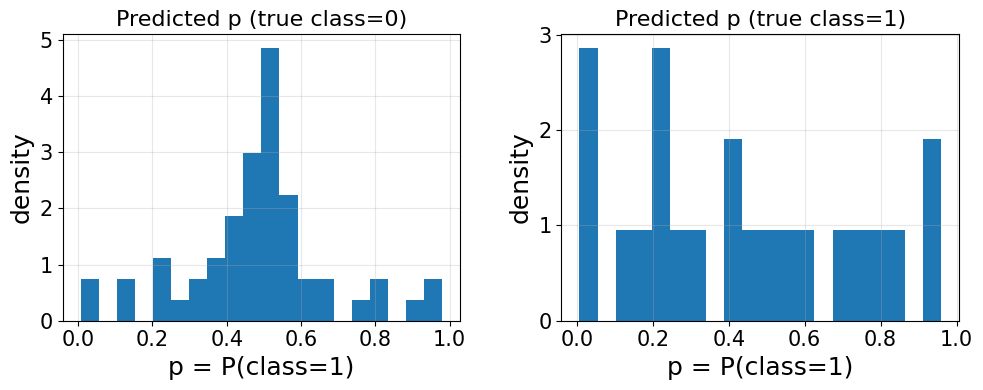

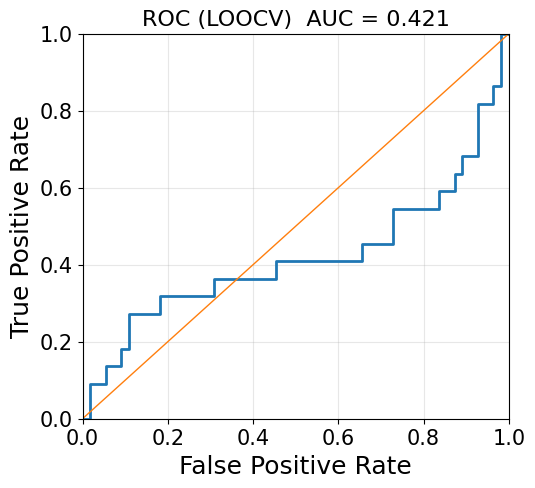


Saved: /content/drive/MyDrive//PNAS_Work/ComparativeAnalysis/LogesticL1/loocv_l1_logistic_results.npz


In [37]:
# ==========================================
# Logistic Regression (LOOCV) on BD-IAT
# X = XF (N x 360) -> reduced to (N x 18) by averaging each 20 block
# y from active_score (binary)
# - Inner CV on training fold to choose C (regularization strength)
# - Deterministic + F1 + confusion matrix + ROC/Hist plots
# ==========================================

MAT_PATH = "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/data_bdiat.mat"
OUT_PATH = "/content/drive/MyDrive//PNAS_Work/ComparativeAnalysis/LogesticL1/loocv_l1_logistic_results.npz"  # <-- change if needed

import os, random
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from sklearn.model_selection import LeaveOneOut, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

# ----------------------------
# 0) Determinism
# ----------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ----------------------------
# 1) Load data (18 features)
# ----------------------------
D = sio.loadmat(MAT_PATH)
X0 = D["XF"].astype(np.float64)
if X0.ndim != 2 or X0.shape[1] != 360:
    raise ValueError(f"Expected XF shape (N, 360), got {X0.shape}")

N0 = X0.shape[0]
X = X0.reshape(N0, 18, 20).mean(axis=2)  # (N, 18)

active_score = D["active_score"].reshape(-1)
classes = np.unique(active_score)
if classes.size != 2:
    raise ValueError(f"active_score must have exactly 2 unique values, got: {classes}")

pos_class = np.max(classes)
y_true = (active_score == pos_class).astype(int)

N, T = X.shape
print(f"Loaded XF: X shape = {X.shape}")
print(f"active_score classes = {classes}, positive class value = {pos_class}")
print(f"Label counts: n0={np.sum(y_true==0)}, n1={np.sum(y_true==1)}")

# ----------------------------
# 2) Inner CV selection for C using AUC on probs
# ----------------------------
def auc_safe(y, scores):
    if np.unique(y).size < 2:
        return np.nan
    return roc_auc_score(y, scores)

def build_logreg(C, seed=42):
    return Pipeline(steps=[
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("lr", LogisticRegression(
            C=C,
            penalty="l2",
            solver="liblinear",
            class_weight="balanced",
            max_iter=5000,
            random_state=seed
        ))
    ])

def select_best_C(Xtr, ytr, C_grid, seed=42):
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    mean_auc_per_C = []

    for C in C_grid:
        fold_aucs = []
        for tr2, va2 in inner_cv.split(Xtr, ytr):
            Xtr2, Xva2 = Xtr[tr2], Xtr[va2]
            ytr2, yva2 = ytr[tr2], ytr[va2]

            model = build_logreg(C, seed=seed)
            model.fit(Xtr2, ytr2)
            p = model.predict_proba(Xva2)[:, 1]
            fold_aucs.append(auc_safe(yva2, p))

        mean_auc_per_C.append(np.nanmean(fold_aucs))

    mean_auc_per_C = np.array(mean_auc_per_C)
    best_idx = int(np.nanargmax(mean_auc_per_C))
    return float(C_grid[best_idx]), mean_auc_per_C

# ----------------------------
# 3) LOOCV
# ----------------------------
loo = LeaveOneOut()
C_grid = np.logspace(-3, 3, 25)

p_hat  = np.zeros(N, dtype=float)
y_hat  = np.zeros(N, dtype=int)
best_C = np.zeros(N, dtype=float)

for fold, (tr_idx, te_idx) in enumerate(loo.split(X), start=1):
    Xtr, Xte = X[tr_idx], X[te_idx]
    ytr, yte = y_true[tr_idx], y_true[te_idx]

    C_sel, _ = select_best_C(Xtr, ytr, C_grid, seed=SEED)
    best_C[te_idx[0]] = C_sel

    model = build_logreg(C_sel, seed=SEED)
    model.fit(Xtr, ytr)

    proba = model.predict_proba(Xte)[0, 1]
    pred  = int(proba >= 0.5)

    p_hat[te_idx[0]] = proba
    y_hat[te_idx[0]] = pred

    if fold % 10 == 0 or fold == 1 or fold == N:
        print(f"Fold {fold:02d}/{N}: test={te_idx[0]}, C={C_sel:.4g}, p={proba:.3f}, yhat={pred}, ytrue={yte[0]}")

# ----------------------------
# 4) Metrics
# ----------------------------
acc  = accuracy_score(y_true, y_hat)
bacc = balanced_accuracy_score(y_true, y_hat)
f1   = f1_score(y_true, y_hat, zero_division=0)
Cmat = confusion_matrix(y_true, y_hat, labels=[0, 1])
tn, fp, fn, tp = Cmat.ravel()

try:
    auc = roc_auc_score(y_true, p_hat)
except ValueError:
    auc = np.nan

print("\n===== Logistic Regression (LOOCV) =====")
print(f"Accuracy:          {acc:.3f}")
print(f"Balanced Accuracy: {bacc:.3f}")
print(f"F1-score:          {f1:.3f}")
print(f"AUC:               {auc:.3f}" if np.isfinite(auc) else "AUC:               NaN")

print("\nConfusion matrix (rows=true [0,1], cols=pred [0,1]):")
print(Cmat)
print("\nTN FP FN TP:")
print(tn, fp, fn, tp)

# ----------------------------
# 5) Plots
# ----------------------------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(p_hat[y_true == 0], bins=20, density=True)
plt.title("Predicted p (true class=0)")
plt.xlabel("p = P(class=1)")
plt.ylabel("density")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(p_hat[y_true == 1], bins=20, density=True)
plt.title("Predicted p (true class=1)")
plt.xlabel("p = P(class=1)")
plt.ylabel("density")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if np.isfinite(auc):
    fpr, tpr, _ = roc_curve(y_true, p_hat)
    plt.figure(figsize=(5.5, 5))
    plt.plot(fpr, tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], linewidth=1)
    plt.title(f"ROC (LOOCV)  AUC = {auc:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.show()

# ----------------------------
# 6) Save
# ----------------------------
np.savez(
    OUT_PATH,
    p_hat=p_hat,
    y_hat=y_hat,
    y_true=y_true,
    best_C=best_C,
    auc=np.array([auc], dtype=np.float64),
    f1=np.array([f1], dtype=np.float64),
    seed=np.array([SEED], dtype=np.int64),
)
print(f"\nSaved: {OUT_PATH}")


Mounted at /content/drive
Loaded XF: X shape = (77, 18)
active_score classes = [0 1], positive class value = 1
Label counts: n0=55, n1=22
Fold 01/77: test=0, C=0.5623, p=0.288, thr=0.327, prev_tr=0.289, yhat=0, ytrue=0, margin=-0.507
Fold 10/77: test=9, C=0.5623, p=0.291, thr=0.329, prev_tr=0.289, yhat=0, ytrue=0, margin=0.225
Fold 20/77: test=19, C=0.3162, p=0.329, thr=0.328, prev_tr=0.289, yhat=1, ytrue=0, margin=-0.440
Fold 30/77: test=29, C=0.003162, p=0.314, thr=0.365, prev_tr=0.289, yhat=0, ytrue=0, margin=0.160
Fold 40/77: test=39, C=0.1, p=0.352, thr=0.329, prev_tr=0.289, yhat=1, ytrue=0, margin=1.542
Fold 50/77: test=49, C=0.01, p=0.317, thr=0.336, prev_tr=0.289, yhat=0, ytrue=0, margin=-0.080
Fold 60/77: test=59, C=3.162, p=0.260, thr=0.305, prev_tr=0.276, yhat=0, ytrue=1, margin=-1.030
Fold 70/77: test=69, C=1.778, p=0.290, thr=0.311, prev_tr=0.276, yhat=0, ytrue=1, margin=-1.237
Fold 77/77: test=76, C=0.001, p=0.264, thr=0.341, prev_tr=0.289, yhat=0, ytrue=0, margin=-0.031


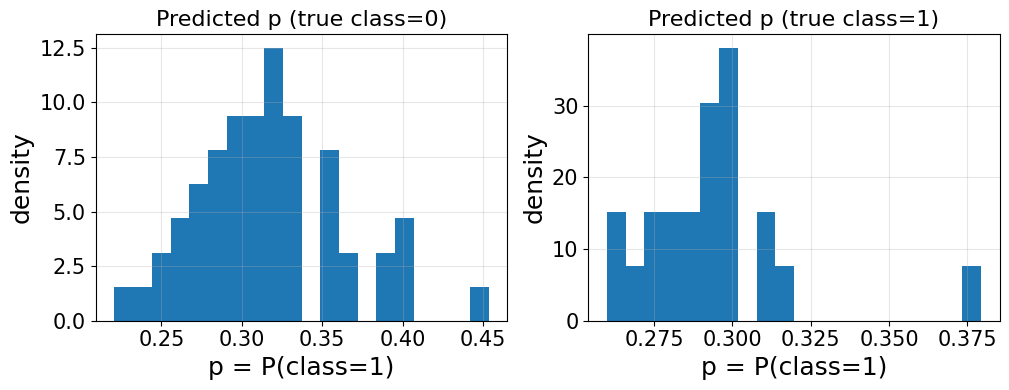

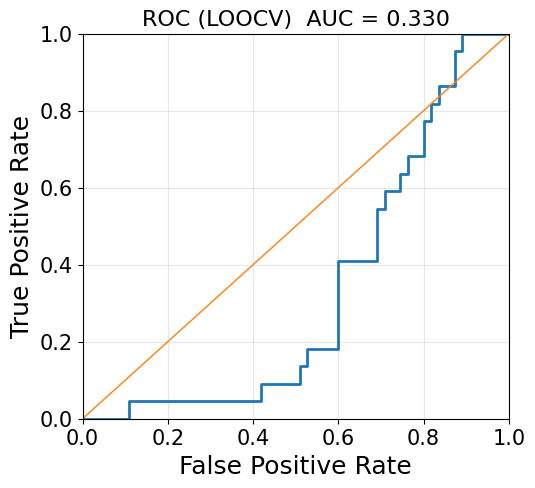


Saved: /content/drive/MyDrive//PNAS_Work/ComparativeAnalysis/SVM/loocv_linear_svm_results.npz


In [41]:
# ==========================================
# Linear SVM (LOOCV) on BD-IAT
# Reads data_bdiat.mat from Google Drive
# X = XF (N x 360) -> averaged to (N x 18)
# y from active_score (binary)
# - Inner CV on training fold to choose C (regularization)
# - Calibrated probabilities (sigmoid)
# - Train-only threshold (prevalence matched) to avoid all-negative at 0.5
# - Deterministic + F1-score
# ==========================================

MAT_PATH = "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/data_bdiat.mat"
OUT_PATH = "/content/drive/MyDrive//PNAS_Work/ComparativeAnalysis/SVM/loocv_linear_svm_results.npz"

import os, random
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from sklearn.model_selection import LeaveOneOut, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

# ----------------------------
# 0) Determinism
# ----------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ----------------------------
# 1) Load data (360 -> 18)
# ----------------------------
D = sio.loadmat(MAT_PATH)

X0 = D["XF"].astype(np.float64)  # (N, 360)
if X0.ndim != 2 or X0.shape[1] != 360:
    raise ValueError(f"Expected XF shape (N, 360), got {X0.shape}")

N0 = X0.shape[0]
X = X0.reshape(N0, 18, 20).mean(axis=2)  # (N, 18)

active_score = D["active_score"].reshape(-1)
classes = np.unique(active_score)
if classes.size != 2:
    raise ValueError(f"active_score must have exactly 2 unique values, got: {classes}")

pos_class = np.max(classes)
y_true = (active_score == pos_class).astype(int)

N, T = X.shape
print(f"Loaded XF: X shape = {X.shape}")
print(f"active_score classes = {classes}, positive class value = {pos_class}")
print(f"Label counts: n0={np.sum(y_true==0)}, n1={np.sum(y_true==1)}")

# ----------------------------
# 2) Inner CV selection for C (AUC on margins)
# ----------------------------
def auc_from_scores(y, scores):
    if np.unique(y).size < 2:
        return np.nan
    return roc_auc_score(y, scores)

def select_best_C_linear_svm(Xtr, ytr, C_grid, seed=42):
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    mean_auc_per_C = []
    for C in C_grid:
        fold_aucs = []
        for tr2, va2 in inner_cv.split(Xtr, ytr):
            Xtr2, Xva2 = Xtr[tr2], Xtr[va2]
            ytr2, yva2 = ytr[tr2], ytr[va2]

            pipe = Pipeline(steps=[
                ("scaler", StandardScaler(with_mean=True, with_std=True)),
                ("svm", LinearSVC(
                    C=C,
                    class_weight="balanced",
                    max_iter=20000,
                    random_state=seed
                ))
            ])
            pipe.fit(Xtr2, ytr2)

            scores = pipe.decision_function(Xva2)
            fold_aucs.append(auc_from_scores(yva2, scores))

        mean_auc_per_C.append(np.nanmean(fold_aucs))

    mean_auc_per_C = np.array(mean_auc_per_C)
    best_idx = int(np.nanargmax(mean_auc_per_C))
    return float(C_grid[best_idx]), mean_auc_per_C

# ----------------------------
# 3) Train-only threshold selection (prevalence matched)
# ----------------------------
def train_only_threshold_prevalence(calibrator, Xtr, ytr):
    """
    Choose threshold using ONLY training fold:
    - compute calibrated probabilities on Xtr
    - set threshold so predicted positive rate matches training prevalence
    This avoids degenerate all-negative predictions when 0.5 is too strict.
    """
    p_tr = calibrator.predict_proba(Xtr)[:, 1]
    prev = float(np.mean(ytr))
    # threshold = quantile at (1 - prev) so fraction prev are predicted positive
    thr = float(np.quantile(p_tr, 1.0 - prev))
    return thr, p_tr, prev

# ----------------------------
# 4) LOOCV
# ----------------------------
loo = LeaveOneOut()
C_grid = np.logspace(-3, 3, 25)

p_hat     = np.zeros(N, dtype=float)
y_hat     = np.zeros(N, dtype=int)
best_C    = np.zeros(N, dtype=float)
raw_score = np.zeros(N, dtype=float)
thr_fold  = np.zeros(N, dtype=float)

for fold, (tr_idx, te_idx) in enumerate(loo.split(X), start=1):
    Xtr, Xte = X[tr_idx], X[te_idx]
    ytr, yte = y_true[tr_idx], y_true[te_idx]

    C_sel, _ = select_best_C_linear_svm(Xtr, ytr, C_grid, seed=SEED)
    best_C[te_idx[0]] = C_sel

    base_pipe = Pipeline(steps=[
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("svm", LinearSVC(C=C_sel, class_weight="balanced", max_iter=20000, random_state=SEED))
    ])

    calibrator = CalibratedClassifierCV(
        estimator=base_pipe,
        method="sigmoid",
        cv=5
    )
    calibrator.fit(Xtr, ytr)

    # --- train-only threshold ---
    thr, _, prev = train_only_threshold_prevalence(calibrator, Xtr, ytr)
    thr_fold[te_idx[0]] = thr

    proba = float(calibrator.predict_proba(Xte)[0, 1])
    pred  = int(proba >= thr)

    p_hat[te_idx[0]] = proba
    y_hat[te_idx[0]] = pred

    # also store margin for reference
    base_pipe.fit(Xtr, ytr)
    raw_score[te_idx[0]] = float(base_pipe.decision_function(Xte)[0])

    if fold % 10 == 0 or fold == 1 or fold == N:
        print(f"Fold {fold:02d}/{N}: test={te_idx[0]}, C={C_sel:.4g}, "
              f"p={proba:.3f}, thr={thr:.3f}, prev_tr={prev:.3f}, "
              f"yhat={pred}, ytrue={yte[0]}, margin={raw_score[te_idx[0]]:.3f}")

# ----------------------------
# 5) Metrics + Confusion matrix
# ----------------------------
acc  = accuracy_score(y_true, y_hat)
bacc = balanced_accuracy_score(y_true, y_hat)
f1   = f1_score(y_true, y_hat, zero_division=0)
Cmat = confusion_matrix(y_true, y_hat, labels=[0, 1])
tn, fp, fn, tp = Cmat.ravel()

try:
    auc = roc_auc_score(y_true, p_hat)
except ValueError:
    auc = np.nan

# (Optional sanity: margin AUC is often more stable than calibrated probs)
try:
    auc_margin = roc_auc_score(y_true, raw_score)
except ValueError:
    auc_margin = np.nan

print("\n===== Linear SVM (Calibrated) (LOOCV) =====")
print(f"Accuracy:          {acc:.3f}")
print(f"Balanced Accuracy: {bacc:.3f}")
print(f"F1-score:          {f1:.3f}")
print(f"AUC (prob):        {auc:.3f}" if np.isfinite(auc) else "AUC (prob):        NaN")
print(f"AUC (margin):      {auc_margin:.3f}" if np.isfinite(auc_margin) else "AUC (margin):      NaN")

print("\nConfusion matrix (rows=true [0,1], cols=pred [0,1]):")
print(Cmat)
print("\nTN FP FN TP:")
print(tn, fp, fn, tp)

# ----------------------------
# 6) PRINT arrays
# ----------------------------
print("\n===== Arrays that will be saved =====")
print(f"p_hat     (shape {p_hat.shape}):\n{p_hat}")
print(f"\ny_hat     (shape {y_hat.shape}):\n{y_hat}")
print(f"\ny_true    (shape {y_true.shape}):\n{y_true}")
print(f"\nbest_C    (shape {best_C.shape}):\n{best_C}")
print(f"\nraw_score (shape {raw_score.shape}):\n{raw_score}")
print(f"\nthr_fold  (shape {thr_fold.shape}):\n{thr_fold}")

# ----------------------------
# 7) Plots
# ----------------------------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(p_hat[y_true == 0], bins=20, density=True)
plt.title("Predicted p (true class=0)")
plt.xlabel("p = P(class=1)")
plt.ylabel("density")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(p_hat[y_true == 1], bins=20, density=True)
plt.title("Predicted p (true class=1)")
plt.xlabel("p = P(class=1)")
plt.ylabel("density")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if np.isfinite(auc):
    fpr, tpr, _ = roc_curve(y_true, p_hat)
    plt.figure(figsize=(5.5, 5))
    plt.plot(fpr, tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], linewidth=1)
    plt.title(f"ROC (LOOCV)  AUC = {auc:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.show()

# ----------------------------
# 8) Save
# ----------------------------
np.savez(
    OUT_PATH,
    p_hat=p_hat,
    y_hat=y_hat,
    y_true=y_true,
    best_C=best_C,
    raw_score=raw_score,
    thr_fold=thr_fold,
    f1=np.array([f1], dtype=np.float64),
    auc_prob=np.array([auc], dtype=np.float64),
    auc_margin=np.array([auc_margin], dtype=np.float64),
    seed=np.array([SEED], dtype=np.int64),
)
print(f"\nSaved: {OUT_PATH}")


Mounted at /content/drive
Loaded XF (block-avg): X shape = (77, 18)
active_score classes = [0 1], positive class value = 1
Label counts: n0=55, n1=22
Fold 01/77: test=0, p=0.878, yhat=1, ytrue=0
Fold 10/77: test=9, p=0.910, yhat=1, ytrue=0
Fold 20/77: test=19, p=0.365, yhat=0, ytrue=0
Fold 30/77: test=29, p=0.688, yhat=1, ytrue=0
Fold 40/77: test=39, p=0.602, yhat=1, ytrue=0
Fold 50/77: test=49, p=0.526, yhat=1, ytrue=0
Fold 60/77: test=59, p=0.000, yhat=0, ytrue=1
Fold 70/77: test=69, p=0.006, yhat=0, ytrue=1
Fold 77/77: test=76, p=0.281, yhat=0, ytrue=0

===== SMALL REG MLP (LOOCV) =====
Accuracy:          0.597
Balanced Accuracy: 0.500
F1-score:          0.279
AUC:               0.507

Confusion matrix (rows=true [0,1], cols=pred [0,1]):
[[40 15]
 [16  6]]

TN FP FN TP:
40 15 16 6

===== Arrays that will be saved =====
p_hat   (shape (77,)):
[8.77640200e-01 8.27855331e-01 3.58100843e-01 1.11583419e-03
 1.02786744e-02 3.37278556e-02 6.05499757e-02 4.85743383e-02
 7.52121400e-02 9.095

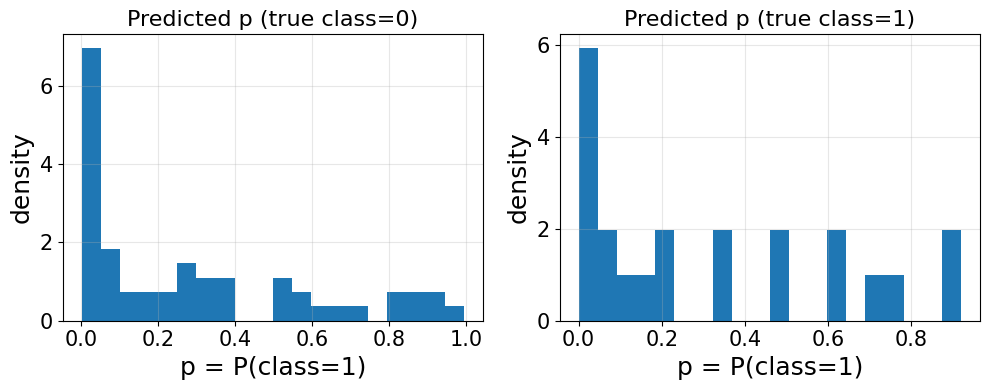

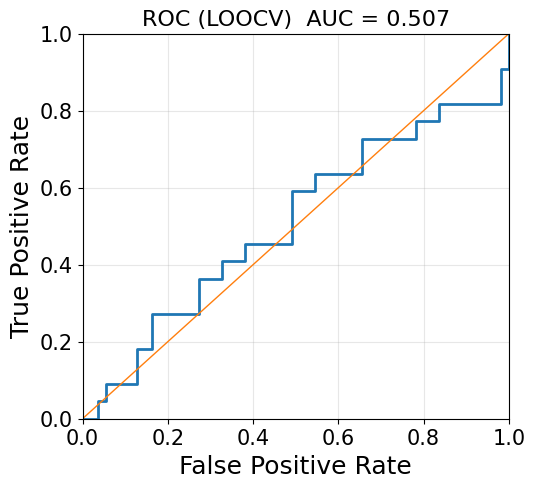


Saved: /content/drive/MyDrive//PNAS_Work/ComparativeAnalysis/MLP/loocv_mlp_results.npz


In [42]:
# ==========================================
# REGULARIZED MLP (LOOCV) on BD-IAT
# Reads data_bdiat.mat from Google Drive
# X = XF (N x 360) -> reduced to (N x 18) by averaging each 20 block
# y from active_score (binary)
# ==========================================

MAT_PATH = "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/data_bdiat.mat"
OUT_PATH = "/content/drive/MyDrive//PNAS_Work/ComparativeAnalysis/MLP/loocv_mlp_results.npz"

import os, random
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

# ----------------------------
# 0) Determinism
# ----------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ----------------------------
# 1) Load data
# ----------------------------
D = sio.loadmat(MAT_PATH)

X0 = D["XF"].astype(np.float64)  # (N, 360)
if X0.ndim != 2 or X0.shape[1] != 360:
    raise ValueError(f"Expected XF shape (N, 360), got {X0.shape}")

N0 = X0.shape[0]
X = X0.reshape(N0, 18, 20).mean(axis=2)  # (N, 18)

active_score = D["active_score"].reshape(-1)
classes = np.unique(active_score)
if classes.size != 2:
    raise ValueError(f"active_score must have exactly 2 unique values, got: {classes}")

pos_class = np.max(classes)
y_true = (active_score == pos_class).astype(int)

N, T = X.shape
print(f"Loaded XF (block-avg): X shape = {X.shape}")
print(f"active_score classes = {classes}, positive class value = {pos_class}")
print(f"Label counts: n0={np.sum(y_true==0)}, n1={np.sum(y_true==1)}")

# ----------------------------
# 2) regularized MLP
# ----------------------------
def build_small_reg_mlp(seed=42):
    return Pipeline(steps=[
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(8,),
            activation="relu",
            solver="lbfgs",
            alpha=1.0,
            max_iter=2000,
            early_stopping=False,
            random_state=seed
        ))
    ])

# ----------------------------
# 3) LOOCV
# ----------------------------
loo = LeaveOneOut()

p_hat = np.zeros(N, dtype=float)
y_hat = np.zeros(N, dtype=int)

for fold, (tr_idx, te_idx) in enumerate(loo.split(X), start=1):
    Xtr, Xte = X[tr_idx], X[te_idx]
    ytr, yte = y_true[tr_idx], y_true[te_idx]

    model = build_small_reg_mlp(seed=SEED)
    model.fit(Xtr, ytr)

    proba = model.predict_proba(Xte)[0, 1]
    pred  = int(proba >= 0.5)

    p_hat[te_idx[0]] = proba
    y_hat[te_idx[0]] = pred

    if fold % 10 == 0 or fold == 1 or fold == N:
        print(f"Fold {fold:02d}/{N}: test={te_idx[0]}, p={proba:.3f}, yhat={pred}, ytrue={yte[0]}")

# ----------------------------
# 4) Metrics + Confusion matrix
# ----------------------------
acc  = accuracy_score(y_true, y_hat)
bacc = balanced_accuracy_score(y_true, y_hat)
f1   = f1_score(y_true, y_hat, zero_division=0)
Cmat = confusion_matrix(y_true, y_hat, labels=[0, 1])

try:
    auc = roc_auc_score(y_true, p_hat)
except ValueError:
    auc = np.nan

print("\n===== SMALL REG MLP (LOOCV) =====")
print(f"Accuracy:          {acc:.3f}")
print(f"Balanced Accuracy: {bacc:.3f}")
print(f"F1-score:          {f1:.3f}")
print(f"AUC:               {auc:.3f}" if np.isfinite(auc) else "AUC:               NaN")

print("\nConfusion matrix (rows=true [0,1], cols=pred [0,1]):")
print(Cmat)
tn, fp, fn, tp = Cmat.ravel()
print("\nTN FP FN TP:")
print(tn, fp, fn, tp)

# ----------------------------
# 5) PRINT what we are saving
# ----------------------------
print("\n===== Arrays that will be saved =====")
print(f"p_hat   (shape {p_hat.shape}):\n{p_hat}")
print(f"\ny_hat   (shape {y_hat.shape}):\n{y_hat}")
print(f"\ny_true  (shape {y_true.shape}):\n{y_true}")

# ----------------------------
# 6) Plots
# ----------------------------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(p_hat[y_true == 0], bins=20, density=True)
plt.title("Predicted p (true class=0)")
plt.xlabel("p = P(class=1)")
plt.ylabel("density")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(p_hat[y_true == 1], bins=20, density=True)
plt.title("Predicted p (true class=1)")
plt.xlabel("p = P(class=1)")
plt.ylabel("density")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if np.isfinite(auc):
    fpr, tpr, _ = roc_curve(y_true, p_hat)
    plt.figure(figsize=(5.5, 5))
    plt.plot(fpr, tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], linewidth=1)
    plt.title(f"ROC (LOOCV)  AUC = {auc:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.show()

# ----------------------------
# 7) Save results
# ----------------------------
np.savez(
    OUT_PATH,
    p_hat=p_hat,
    y_hat=y_hat,
    y_true=y_true,
    auc=np.array([auc], dtype=np.float64),
    f1=np.array([f1], dtype=np.float64),
    seed=np.array([SEED], dtype=np.int64),
)
print(f"\nSaved: {OUT_PATH}")


Mounted at /content/drive
Loaded XF: X shape = (77, 360)
active_score classes = [0 1], positive class value = 1
Label counts: n0=55, n1=22, pos_rate=0.286
Torch device: cuda
Fold 01/77: test=0, p=0.503, flip=True, ytrue=0, best_val_metric=0.764
Fold 10/77: test=9, p=0.503, flip=True, ytrue=0, best_val_metric=0.745
Fold 20/77: test=19, p=0.503, flip=True, ytrue=0, best_val_metric=0.582
Fold 30/77: test=29, p=0.504, flip=True, ytrue=0, best_val_metric=0.691
Fold 40/77: test=39, p=0.492, flip=False, ytrue=0, best_val_metric=0.600
Fold 50/77: test=49, p=0.496, flip=False, ytrue=0, best_val_metric=0.636
Fold 60/77: test=59, p=0.509, flip=True, ytrue=1, best_val_metric=0.583
Fold 70/77: test=69, p=0.509, flip=True, ytrue=1, best_val_metric=0.583
Fold 77/77: test=76, p=0.498, flip=False, ytrue=0, best_val_metric=0.600

===== FAST LSTM (LOOCV) - FAIR CONSERVATIVE (VAL flip, quantile threshold) =====
AUC:               0.712
Threshold (quantile): 0.5030  | pos_rate=0.286
Accuracy:          0.74

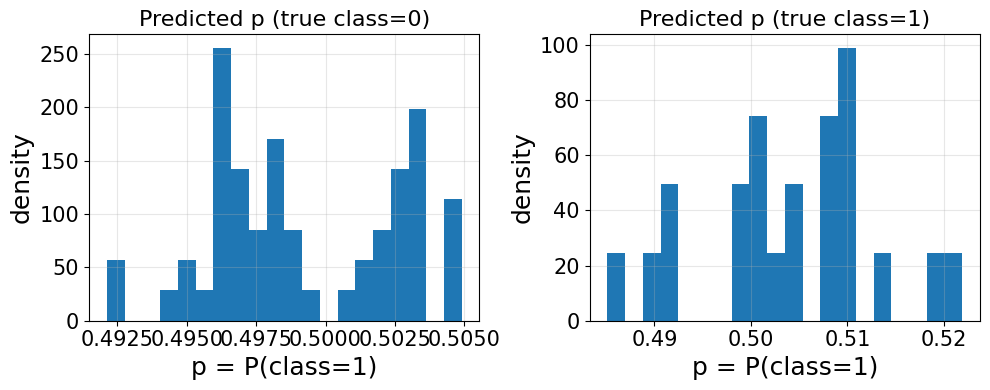

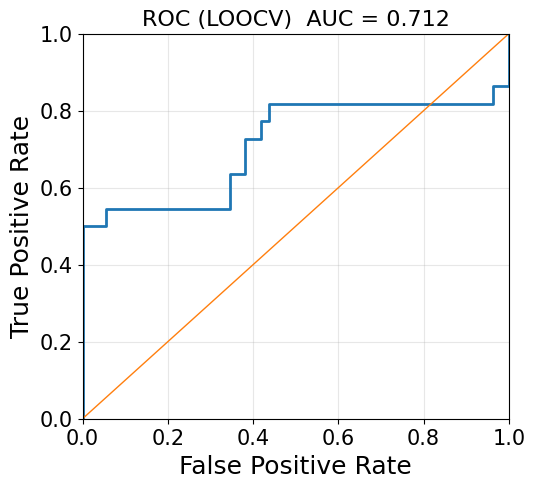


Saved: /content/drive/MyDrive//PNAS_Work/ComparativeAnalysis/LSTM/loocv_lstm_results.npz


In [43]:
# ==========================================
# LSTM (LOOCV) on BD-IAT (GPU if available)
# - Early stopping uses inner VAL (training fold only)
# - Orientation (flip) decided using inner VAL AUC only
# ==========================================

MAT_PATH = "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/data_bdiat.mat"
OUT_PATH = "/content/drive/MyDrive//PNAS_Work/ComparativeAnalysis/LSTM/loocv_lstm_results.npz"

import os, random
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import LeaveOneOut, StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

# ----------------------------
# 0) GLOBAL DETERMINISM
# ----------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

# ----------------------------
# 1) Load data
# ----------------------------
D = sio.loadmat(MAT_PATH)
X = D["XF"].astype(np.float32)  # (N, 360)
active_score = D["active_score"].reshape(-1)

classes = np.unique(active_score)
if classes.size != 2:
    raise ValueError(f"active_score must have exactly 2 unique values, got: {classes}")

pos_class = np.max(classes)
y_true = (active_score == pos_class).astype(np.int64)

N, T = X.shape
pos_rate = float(y_true.mean())

print(f"Loaded XF: X shape = {X.shape}")
print(f"active_score classes = {classes}, positive class value = {pos_class}")
print(f"Label counts: n0={np.sum(y_true==0)}, n1={np.sum(y_true==1)}, pos_rate={pos_rate:.3f}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch device:", device)

# ----------------------------
# 2) Standardization (train-fold only)
# ----------------------------
def fit_standardizer(Xtrain):
    mu = Xtrain.mean(axis=0)
    sd = Xtrain.std(axis=0)
    sd = np.where(sd < 1e-8, 1.0, sd)
    return mu, sd

def apply_standardizer(Xdata, mu, sd):
    return (Xdata - mu) / sd

class SeqDataset(Dataset):
    def __init__(self, X_seq, y):
        self.X = torch.from_numpy(X_seq).float().unsqueeze(-1)  # (N,T,1)
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ----------------------------
# 3) Model
# ----------------------------
class LSTMClassifier(nn.Module):
    def __init__(self, hidden_dim=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0),
            bidirectional=False
        )
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        h_last = out[:, -1, :]
        h_last = self.drop(h_last)
        logits = self.fc(h_last).squeeze(-1)
        return logits

# ----------------------------
# 4) Train with early stopping
# ----------------------------
def train_lstm_one_fold(Xtr, ytr, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    tr2_idx, va2_idx = next(splitter.split(Xtr, ytr))

    Xtr2, ytr2 = Xtr[tr2_idx], ytr[tr2_idx]
    Xva2, yva2 = Xtr[va2_idx], ytr[va2_idx]

    ds_tr = SeqDataset(Xtr2, ytr2)
    ds_va = SeqDataset(Xva2, yva2)

    g = torch.Generator()
    g.manual_seed(seed)

    dl_tr = DataLoader(ds_tr, batch_size=16, shuffle=True, generator=g, pin_memory=True, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=64, shuffle=False, pin_memory=True, num_workers=0)

    model = LSTMClassifier(hidden_dim=32, num_layers=1, dropout=0.2).to(device)

    n_pos = max(1, int((ytr2 == 1).sum()))
    n_neg = max(1, int((ytr2 == 0).sum()))
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    best_metric = -np.inf
    best_state = None
    best_flip = False
    patience = 15
    patience_left = patience

    for epoch in range(1, 151):
        model.train()
        for xb, yb in dl_tr:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).float()

            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        all_p, all_y = [], []
        with torch.no_grad():
            for xb, yb in dl_va:
                xb = xb.to(device, non_blocking=True)
                p = torch.sigmoid(model(xb)).detach().cpu().numpy()
                all_p.append(p)
                all_y.append(yb.numpy())

        p_va = np.concatenate(all_p).astype(float)
        y_va = np.concatenate(all_y).astype(int)

        if np.unique(y_va).size < 2:
            metric = balanced_accuracy_score(y_va, (p_va >= 0.5).astype(int))
            flip = False
        else:
            auc1 = roc_auc_score(y_va, p_va)
            auc2 = roc_auc_score(y_va, 1.0 - p_va)
            flip = (auc2 > auc1)
            metric = max(auc1, auc2)

        if metric > best_metric + 1e-4:
            best_metric = metric
            best_flip = flip
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    return model, float(best_metric), bool(best_flip)

def predict_proba(model, x_seq_std):
    model.eval()
    xb = torch.from_numpy(x_seq_std).float().unsqueeze(0).unsqueeze(-1).to(device)
    with torch.no_grad():
        p = torch.sigmoid(model(xb)).cpu().numpy()[0]
    return float(p)

# ----------------------------
# 5) LOOCV
# ----------------------------
loo = LeaveOneOut()
p_hat = np.zeros(N, dtype=float)
flip_used = np.zeros(N, dtype=int)
val_metric = np.zeros(N, dtype=float)

for fold, (tr_idx, te_idx) in enumerate(loo.split(X), start=1):
    Xtr_raw, Xte_raw = X[tr_idx], X[te_idx]
    ytr, yte = y_true[tr_idx], y_true[te_idx]

    mu, sd = fit_standardizer(Xtr_raw)
    Xtr = apply_standardizer(Xtr_raw, mu, sd)
    Xte = apply_standardizer(Xte_raw, mu, sd).reshape(-1)

    model, best_val, flip = train_lstm_one_fold(Xtr, ytr, seed=SEED)
    val_metric[te_idx[0]] = best_val
    flip_used[te_idx[0]] = int(flip)

    p = predict_proba(model, Xte)
    p = (1.0 - p) if flip else p
    p_hat[te_idx[0]] = p

    if fold % 10 == 0 or fold == 1 or fold == N:
        print(f"Fold {fold:02d}/{N}: test={te_idx[0]}, p={p:.3f}, flip={flip}, ytrue={yte[0]}, best_val_metric={best_val:.3f}")

# ----------------------------
# 6) LABEL-FREE THRESHOLDING
# ----------------------------
q = 1.0 - pos_rate
thr = float(np.quantile(p_hat, q))
y_hat = (p_hat >= thr).astype(int)

# ----------------------------
# 7) Metrics
# ----------------------------
acc  = accuracy_score(y_true, y_hat)
bacc = balanced_accuracy_score(y_true, y_hat)
f1   = f1_score(y_true, y_hat, zero_division=0)
Cmat = confusion_matrix(y_true, y_hat, labels=[0, 1])
tn, fp, fn, tp = Cmat.ravel()

sens = tp / max(1, tp + fn)
spec = tn / max(1, tn + fp)

try:
    auc = roc_auc_score(y_true, p_hat)
except ValueError:
    auc = np.nan

print("\n===== FAST LSTM (LOOCV) - FAIR CONSERVATIVE (VAL flip, quantile threshold) =====")
print(f"AUC:               {auc:.3f}" if np.isfinite(auc) else "AUC:               NaN")
print(f"Threshold (quantile): {thr:.4f}  | pos_rate={pos_rate:.3f}")
print(f"Accuracy:          {acc:.3f}")
print(f"Balanced Accuracy: {bacc:.3f}")
print(f"F1-score:          {f1:.3f}")
print(f"Sensitivity:       {sens:.3f}")
print(f"Specificity:       {spec:.3f}")

print("\nConfusion matrix (rows=true [0,1], cols=pred [0,1]):")
print(Cmat)
print("\nTN FP FN TP:")
print(tn, fp, fn, tp)

# ----------------------------
# 8) Plots
# ----------------------------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(p_hat[y_true == 0], bins=20, density=True)
plt.title("Predicted p (true class=0)")
plt.xlabel("p = P(class=1)")
plt.ylabel("density")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(p_hat[y_true == 1], bins=20, density=True)
plt.title("Predicted p (true class=1)")
plt.xlabel("p = P(class=1)")
plt.ylabel("density")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if np.isfinite(auc):
    fpr, tpr, _ = roc_curve(y_true, p_hat)
    plt.figure(figsize=(5.5, 5))
    plt.plot(fpr, tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], linewidth=1)
    plt.title(f"ROC (LOOCV)  AUC = {auc:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1]); plt.ylim([0, 1])
    plt.show()

# ----------------------------
# 9) Save results
# ----------------------------
np.savez(
    OUT_PATH,
    p_hat=p_hat,
    y_hat=y_hat,
    y_true=y_true,
    val_metric=val_metric,
    flip_used=flip_used,
    threshold=np.array([thr], dtype=np.float64),
    pos_rate=np.array([pos_rate], dtype=np.float64),
    auc=np.array([auc], dtype=np.float64),
    f1=np.array([f1], dtype=np.float64),
    seed=np.array([SEED], dtype=np.int64),
)
print(f"\nSaved: {OUT_PATH}")


Mounted at /content/drive
Loaded XF: X shape = (77, 360)
active_score classes = [0 1], positive class value = 1
Label counts: n0=55, n1=22
Torch device: cuda
Fold 01/77: test=0, p=0.572, yhat=1, ytrue=0
Fold 10/77: test=9, p=0.438, yhat=0, ytrue=0
Fold 20/77: test=19, p=0.440, yhat=0, ytrue=0
Fold 30/77: test=29, p=0.711, yhat=1, ytrue=0
Fold 40/77: test=39, p=0.483, yhat=0, ytrue=0
Fold 50/77: test=49, p=0.397, yhat=0, ytrue=0
Fold 60/77: test=59, p=0.349, yhat=0, ytrue=1
Fold 70/77: test=69, p=0.178, yhat=0, ytrue=1
Fold 77/77: test=76, p=0.413, yhat=0, ytrue=0

AUC (raw p_hat): 0.3140495867768595
AUC (1 - p_hat): 0.6859504132231405
Final AUC: 0.6859504132231405 | flipped: True
Pairwise AUC-like check: 0.6859504132231405

===== FAST 1D-CNN (NO-VAL) (LOOCV) =====
Accuracy:          0.455
Balanced Accuracy: 0.509
F1-score:          0.400
AUC:               0.686

Confusion matrix (rows=true [0,1], cols=pred [0,1]):
[[21 34]
 [ 8 14]]

TN FP FN TP:
21 34 8 14

===== Arrays that will be 

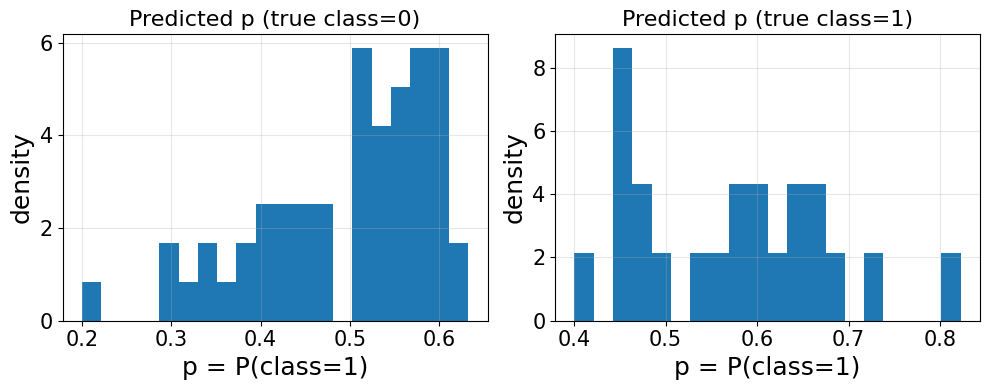

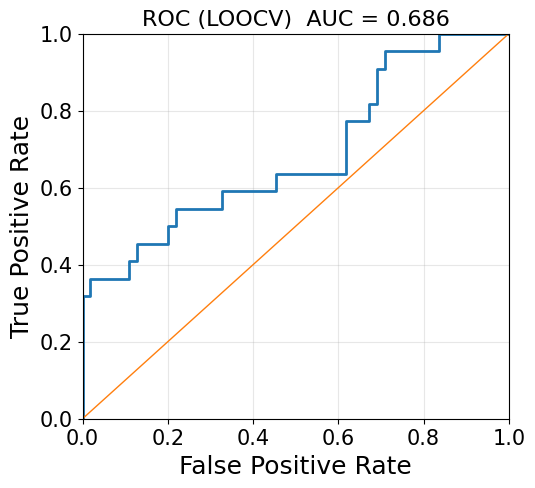


Saved: /content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/1DCNN/loocv_1dcnn_FAST_noval.npz


In [44]:
# ==========================================
# 1D-CNN (LOOCV)
# Includes AUTO-FLIP + extra sanity checks for AUC.
# ==========================================

MAT_PATH = "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/data_bdiat.mat"
OUT_PATH = "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/1DCNN/loocv_1dcnn_FAST_noval.npz"

import os, random
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

# ----------------------------
# 0) GLOBAL DETERMINISM
# ----------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # CUDA matmul determinism on many setups

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

# ----------------------------
# Load data
# ----------------------------
D = sio.loadmat(MAT_PATH)
X = D["XF"].astype(np.float32)  # (N, 360)
active_score = D["active_score"].reshape(-1)

classes = np.unique(active_score)
if classes.size != 2:
    raise ValueError(f"active_score must have exactly 2 unique values, got: {classes}")

pos_class = np.max(classes)
y_true = (active_score == pos_class).astype(np.int64)

N, T = X.shape
print(f"Loaded XF: X shape = {X.shape}")
print(f"active_score classes = {classes}, positive class value = {pos_class}")
print(f"Label counts: n0={np.sum(y_true==0)}, n1={np.sum(y_true==1)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch device:", device)

# ----------------------------
# Standardization (train-only)
# ----------------------------
def fit_standardizer_1d(Xtrain):
    mu = Xtrain.mean(axis=0)
    sd = Xtrain.std(axis=0)
    sd = np.where(sd < 1e-8, 1.0, sd)
    return mu, sd

def apply_standardizer_1d(Xdata, mu, sd):
    return (Xdata - mu) / sd

# ----------------------------
# Dataset
# ----------------------------
class SeqDatasetCNN(Dataset):
    def __init__(self, X_seq, y):
        self.X = torch.from_numpy(X_seq).float().unsqueeze(1)  # (N,1,T)
        self.y = torch.from_numpy(y).long()

    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# ----------------------------
# Model
# ----------------------------
class CNN1DClassifier(nn.Module):
    def __init__(self, n_filters=16, kernel_size=7, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv1d(1, n_filters, kernel_size, padding=pad),
            nn.ReLU(),
            nn.Conv1d(n_filters, n_filters, kernel_size, padding=pad),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(n_filters, 2*n_filters, kernel_size, padding=pad),
            nn.ReLU(),
            nn.Conv1d(2*n_filters, 2*n_filters, kernel_size, padding=pad),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Dropout(dropout)
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(2*n_filters, 1)

    def forward(self, x):
        h = self.net(x)
        h = self.gap(h).squeeze(-1)
        return self.fc(h).squeeze(-1)

def train_fixed_epochs(Xtr, ytr, seed=42,
                       n_filters=16, kernel_size=7, dropout=0.2,
                       lr=1e-3, weight_decay=1e-4,
                       batch_size=16, epochs=60):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    ds = SeqDatasetCNN(Xtr, ytr)

    g = torch.Generator()
    g.manual_seed(seed)

    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        pin_memory=True,
        num_workers=0
    )

    model = CNN1DClassifier(n_filters=n_filters, kernel_size=kernel_size, dropout=dropout).to(device)

    n_pos = max(1, int((ytr == 1).sum()))
    n_neg = max(1, int((ytr == 0).sum()))
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.train()
    for ep in range(1, epochs + 1):
        for xb, yb in dl:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).float()

            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

    return model

def predict_proba(model, x_std_1d):
    model.eval()
    xb = torch.from_numpy(x_std_1d).float().unsqueeze(0).unsqueeze(0).to(device)  # (1,1,T)
    with torch.no_grad():
        logit = model(xb).detach().cpu().numpy()[0]
        return float(1.0 / (1.0 + np.exp(-logit)))

# ----------------------------
# LOOCV
# ----------------------------
loo = LeaveOneOut()
p_hat = np.zeros(N, dtype=float)
y_hat = np.zeros(N, dtype=int)

CFG = dict(n_filters=16, kernel_size=7, dropout=0.2, epochs=60)

for fold, (tr_idx, te_idx) in enumerate(loo.split(X), start=1):
    Xtr_raw, Xte_raw = X[tr_idx], X[te_idx]
    ytr, yte = y_true[tr_idx], y_true[te_idx]

    mu, sd = fit_standardizer_1d(Xtr_raw)
    Xtr = apply_standardizer_1d(Xtr_raw, mu, sd)
    Xte = apply_standardizer_1d(Xte_raw, mu, sd).reshape(-1)

    model = train_fixed_epochs(
        Xtr, ytr, seed=SEED,
        n_filters=CFG["n_filters"],
        kernel_size=CFG["kernel_size"],
        dropout=CFG["dropout"],
        epochs=CFG["epochs"]
    )

    proba = predict_proba(model, Xte)
    pred = int(proba >= 0.5)

    idx = te_idx[0]
    p_hat[idx] = proba
    y_hat[idx] = pred

    if fold % 10 == 0 or fold == 1 or fold == N:
        print(f"Fold {fold:02d}/{N}: test={idx}, p={proba:.3f}, yhat={pred}, ytrue={yte[0]}")

# ----------------------------
# AUC sanity checks + auto flip
# ----------------------------
auc_raw  = roc_auc_score(y_true, p_hat)
auc_flip = roc_auc_score(y_true, 1.0 - p_hat)

print("\nAUC (raw p_hat):", auc_raw)
print("AUC (1 - p_hat):", auc_flip)

flipped = False
if auc_flip > auc_raw:
    p_hat = 1.0 - p_hat
    y_hat = (p_hat >= 0.5).astype(int)
    flipped = True

auc = roc_auc_score(y_true, p_hat)
print("Final AUC:", auc, "| flipped:", flipped)

pos = p_hat[y_true == 1]
neg = p_hat[y_true == 0]
pair = 0.0
cnt = 0
for a in pos:
    pair += np.sum(a > neg) + 0.5*np.sum(a == neg)
    cnt += neg.size
pair_auc_like = pair / cnt
print("Pairwise AUC-like check:", pair_auc_like)

# ----------------------------
# Metrics + confusion
# ----------------------------
acc  = accuracy_score(y_true, y_hat)
bacc = balanced_accuracy_score(y_true, y_hat)
f1   = f1_score(y_true, y_hat, zero_division=0)
Cmat = confusion_matrix(y_true, y_hat, labels=[0, 1])
tn, fp, fn, tp = Cmat.ravel()

print("\n===== FAST 1D-CNN (NO-VAL) (LOOCV) =====")
print(f"Accuracy:          {acc:.3f}")
print(f"Balanced Accuracy: {bacc:.3f}")
print(f"F1-score:          {f1:.3f}")
print(f"AUC:               {auc:.3f}")
print("\nConfusion matrix (rows=true [0,1], cols=pred [0,1]):")
print(Cmat)
print("\nTN FP FN TP:")
print(tn, fp, fn, tp)

# ----------------------------
# Print arrays to be saved
# ----------------------------
print("\n===== Arrays that will be saved =====")
print(f"p_hat      (shape {p_hat.shape}):\n{p_hat}")
print(f"\ny_hat      (shape {y_hat.shape}):\n{y_hat}")
print(f"\ny_true     (shape {y_true.shape}):\n{y_true}")
print(f"\nauc_raw={auc_raw:.6f}, auc_flip={auc_flip:.6f}, flipped={flipped}, f1={f1:.6f}")
print("Fixed cfg:", CFG)

# ----------------------------
# Plots
# ----------------------------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(p_hat[y_true == 0], bins=20, density=True)
plt.title("Predicted p (true class=0)")
plt.xlabel("p = P(class=1)")
plt.ylabel("density")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(p_hat[y_true == 1], bins=20, density=True)
plt.title("Predicted p (true class=1)")
plt.xlabel("p = P(class=1)")
plt.ylabel("density")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_true, p_hat)
plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], linewidth=1)
plt.title(f"ROC (LOOCV)  AUC = {auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True, alpha=0.3)
plt.xlim([0, 1]); plt.ylim([0, 1])
plt.show()

# ----------------------------
# Save
# ----------------------------
np.savez(
    OUT_PATH,
    p_hat=p_hat,
    y_hat=y_hat,
    y_true=y_true,
    cfg_filters=np.array([CFG["n_filters"]], dtype=np.int64),
    cfg_kernel=np.array([CFG["kernel_size"]], dtype=np.int64),
    cfg_drop=np.array([CFG["dropout"]], dtype=np.float32),
    epochs=np.array([CFG["epochs"]], dtype=np.int64),
    auc_raw=np.array([auc_raw], dtype=np.float64),
    auc_flip=np.array([auc_flip], dtype=np.float64),
    flipped=np.array([int(flipped)], dtype=np.int64),
    auc=np.array([auc], dtype=np.float64),
    f1=np.array([f1], dtype=np.float64),
    seed=np.array([SEED], dtype=np.int64),
)
print(f"\nSaved: {OUT_PATH}")



Mounted at /content/drive
Loaded XF: X shape = (77, 360)
active_score classes = [0 1], positive class value = 1
Label counts: n0=55, n1=22
Torch device: cuda


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Fold 01/77: test=0, p=0.340, yhat=0, ytrue=0, best_val_metric=0.673


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_

Fold 10/77: test=9, p=0.587, yhat=1, ytrue=0, best_val_metric=0.673


...

Fold 60/77: test=59, p=0.517, yhat=1, ytrue=1, best_val_metric=0.708


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_

Fold 70/77: test=69, p=0.494, yhat=0, ytrue=1, best_val_metric=0.667


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_

Fold 77/77: test=76, p=0.696, yhat=1, ytrue=0, best_val_metric=0.582

AUC (raw p_hat): 0.5388429752066116
AUC (1 - p_hat): 0.46115702479338844
Final AUC: 0.5388429752066116 | flipped: False

===== Transformer Encoder (FAST) (LOOCV) =====
Accuracy:          0.519
Balanced Accuracy: 0.527
F1-score:          0.393
AUC:               0.539

Confusion matrix (rows=true [0,1], cols=pred [0,1]):
[[28 27]
 [10 12]]

TN FP FN TP:
28 27 10 12

===== Arrays that will be saved =====
p_hat      (shape (77,)):
[0.34037906 0.57027388 0.35164893 0.70924675 0.57172906 0.69728285
 0.62578833 0.58280289 0.46963304 0.5873853  0.35646462 0.41902399
 0.74218827 0.48643327 0.77008992 0.4679997  0.60987532 0.4678866
 0.53798091 0.55043101 0.50284493 0.60367191 0.47259885 0.68027198
 0.49647367 0.37009123 0.47604129 0.54398984 0.68804204 0.71014363
 0.47662544 0.65203249 0.43988127 0.44099557 0.4810876  0.42979518
 0.48049575 0.53755635 0.50590211 0.46172586 0.59652436 0.5008232
 0.45706496 0.62586755 0.785122

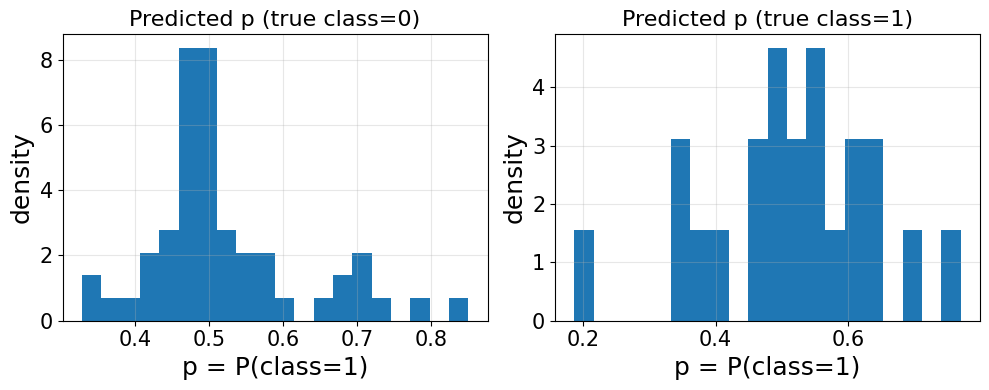

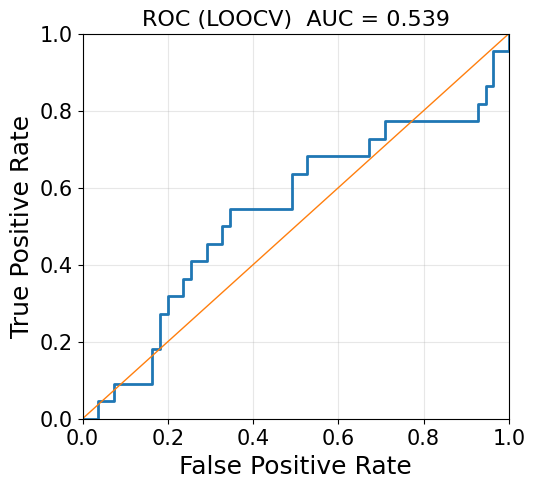


Saved: /content/drive/MyDrive//PNAS_Work/ComparativeAnalysis/Transformer/loocv_transformer_fast.npz


In [11]:
# ==========================================
# Transformer Encoder (LOOCV) on BD-IAT (GPU-ready)
# Reads data_bdiat.mat from Google Drive
# X = XF (N x 360), y from active_score (binary)
# ==========================================

MAT_PATH = "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/data_bdiat.mat"  # <-- change if needed
OUT_PATH = "/content/drive/MyDrive//PNAS_Work/ComparativeAnalysis/Transformer/loocv_transformer_fast.npz"  # <-- change if needed

import os, random
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import LeaveOneOut, StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

# ----------------------------
# 0) GLOBAL DETERMINISM
# ----------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

# ----------------------------
# 1) Load data
# ----------------------------
D = sio.loadmat(MAT_PATH)

X = D["XF"].astype(np.float32)  # (N, 360)
active_score = D["active_score"].reshape(-1)
classes = np.unique(active_score)
if classes.size != 2:
    raise ValueError(f"active_score must have exactly 2 unique values, got: {classes}")

pos_class = np.max(classes)
y_true = (active_score == pos_class).astype(np.int64)

N, T = X.shape
print(f"Loaded XF: X shape = {X.shape}")
print(f"active_score classes = {classes}, positive class value = {pos_class}")
print(f"Label counts: n0={np.sum(y_true==0)}, n1={np.sum(y_true==1)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch device:", device)

# ----------------------------
# 2) Standardization (train-fold only)
# ----------------------------
def fit_standardizer_1d(Xtrain):
    mu = Xtrain.mean(axis=0)
    sd = Xtrain.std(axis=0)
    sd = np.where(sd < 1e-8, 1.0, sd)
    return mu, sd

def apply_standardizer_1d(Xdata, mu, sd):
    return (Xdata - mu) / sd

# ----------------------------
# 3) Dataset
# ----------------------------
class SeqDatasetTF(Dataset):
    def __init__(self, X_seq, y):
        # X_seq: (N,T) float32
        self.X = torch.from_numpy(X_seq).float()   # (N,T)
        self.y = torch.from_numpy(y).long()        # (N,)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ----------------------------
# 4) Transformer model
# ----------------------------
class PositionalEncoding(nn.Module):
    """
    Standard sinusoidal positional encoding.
    """
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        T = x.shape[1]
        return x + self.pe[:, :T, :]

class TransformerClassifier(nn.Module):
    def __init__(self, d_model=32, nhead=4, num_layers=2, dim_ff=64, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=1024)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation="relu",
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        h = self.input_proj(x)      # (B,T,d_model)
        h = self.pos_enc(h)
        h = self.encoder(h)         # (B,T,d_model)
        h = h[:, -1, :]             # last token
        h = self.dropout(h)
        logits = self.fc(h).squeeze(-1)
        return logits

# ----------------------------
# 5) Train one fold with early stopping
# ----------------------------
def train_transformer_one_fold(Xtr, ytr, seed=42):
    """
    Fixed config Transformer. Early stopping on stratified split within training fold.
    Returns trained model and best validation metric.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    tr2_idx, va2_idx = next(splitter.split(Xtr, ytr))

    Xtr2, ytr2 = Xtr[tr2_idx], ytr[tr2_idx]
    Xva2, yva2 = Xtr[va2_idx], ytr[va2_idx]

    ds_tr = SeqDatasetTF(Xtr2, ytr2)
    ds_va = SeqDatasetTF(Xva2, yva2)

    g = torch.Generator()
    g.manual_seed(seed)

    dl_tr = DataLoader(ds_tr, batch_size=16, shuffle=True, generator=g, pin_memory=True, num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=64, shuffle=False, pin_memory=True, num_workers=0)

    model = TransformerClassifier(
        d_model=32, nhead=4, num_layers=2, dim_ff=64, dropout=0.2
    ).to(device)

    n_pos = max(1, int((ytr2 == 1).sum()))
    n_neg = max(1, int((ytr2 == 0).sum()))
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    best_metric = -np.inf
    best_state = None
    patience = 15
    patience_left = patience

    for epoch in range(1, 151):
        model.train()
        for xb, yb in dl_tr:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).float()

            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        all_p, all_y = [], []
        with torch.no_grad():
            for xb, yb in dl_va:
                xb = xb.to(device, non_blocking=True)
                p = torch.sigmoid(model(xb)).detach().cpu().numpy()
                all_p.append(p)
                all_y.append(yb.numpy())

        p_va = np.concatenate(all_p)
        y_va = np.concatenate(all_y)

        if np.unique(y_va).size < 2:
            yhat_va = (p_va >= 0.5).astype(int)
            metric = balanced_accuracy_score(y_va, yhat_va)
        else:
            metric = roc_auc_score(y_va, p_va)

        if metric > best_metric + 1e-4:
            best_metric = metric
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    return model, float(best_metric)

def predict_proba(model, x_seq_std_1d):
    model.eval()
    xb = torch.from_numpy(x_seq_std_1d).float().unsqueeze(0).to(device)  # (1,T)
    with torch.no_grad():
        logit = model(xb).detach().cpu().numpy()[0]
        p = 1.0 / (1.0 + np.exp(-logit))
    return float(p)

# ----------------------------
# 6) LOOCV
# ----------------------------
loo = LeaveOneOut()
p_hat = np.zeros(N, dtype=float)
y_hat = np.zeros(N, dtype=int)
val_metric = np.zeros(N, dtype=float)

for fold, (tr_idx, te_idx) in enumerate(loo.split(X), start=1):
    Xtr_raw, Xte_raw = X[tr_idx], X[te_idx]
    ytr, yte = y_true[tr_idx], y_true[te_idx]

    mu, sd = fit_standardizer_1d(Xtr_raw)
    Xtr = apply_standardizer_1d(Xtr_raw, mu, sd)
    Xte = apply_standardizer_1d(Xte_raw, mu, sd).reshape(-1)

    model, best_val = train_transformer_one_fold(Xtr, ytr, seed=SEED)
    val_metric[te_idx[0]] = best_val

    proba = predict_proba(model, Xte)
    pred = int(proba >= 0.5)

    p_hat[te_idx[0]] = proba
    y_hat[te_idx[0]] = pred

    if fold % 10 == 0 or fold == 1 or fold == N:
        print(f"Fold {fold:02d}/{N}: test={te_idx[0]}, p={proba:.3f}, yhat={pred}, ytrue={yte[0]}, best_val_metric={best_val:.3f}")

# ----------------------------
# 7) AUTO-FLIP ORIENTATION
# ----------------------------
auc_raw = roc_auc_score(y_true, p_hat)
auc_flip = roc_auc_score(y_true, 1.0 - p_hat)

print("\nAUC (raw p_hat):", auc_raw)
print("AUC (1 - p_hat):", auc_flip)

flipped = False
if auc_flip > auc_raw:
    p_hat = 1.0 - p_hat
    y_hat = (p_hat >= 0.5).astype(int)
    flipped = True

auc = roc_auc_score(y_true, p_hat)
print("Final AUC:", auc, "| flipped:", flipped)

# ----------------------------
# 8) Metrics + Confusion matrix (+ F1)  (ONLY CHANGE: added F1)
# ----------------------------
acc  = accuracy_score(y_true, y_hat)
bacc = balanced_accuracy_score(y_true, y_hat)
f1   = f1_score(y_true, y_hat, zero_division=0)
Cmat = confusion_matrix(y_true, y_hat, labels=[0, 1])

print("\n===== Transformer Encoder (FAST) (LOOCV) =====")
print(f"Accuracy:          {acc:.3f}")
print(f"Balanced Accuracy: {bacc:.3f}")
print(f"F1-score:          {f1:.3f}")
print(f"AUC:               {auc:.3f}")

print("\nConfusion matrix (rows=true [0,1], cols=pred [0,1]):")
print(Cmat)
tn, fp, fn, tp = Cmat.ravel()
print("\nTN FP FN TP:")
print(tn, fp, fn, tp)

# ----------------------------
# 9) Print arrays to be saved
# ----------------------------
print("\n===== Arrays that will be saved =====")
print(f"p_hat      (shape {p_hat.shape}):\n{p_hat}")
print(f"\ny_hat      (shape {y_hat.shape}):\n{y_hat}")
print(f"\ny_true     (shape {y_true.shape}):\n{y_true}")
print(f"\nval_metric (shape {val_metric.shape}):\n{val_metric}")
print(f"\nauc_raw={auc_raw:.6f}, auc_flip={auc_flip:.6f}, flipped={flipped}, f1={f1:.6f}")

# ----------------------------
# 10) Plots
# ----------------------------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(p_hat[y_true == 0], bins=20, density=True)
plt.title("Predicted p (true class=0)")
plt.xlabel("p = P(class=1)")
plt.ylabel("density")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(p_hat[y_true == 1], bins=20, density=True)
plt.title("Predicted p (true class=1)")
plt.xlabel("p = P(class=1)")
plt.ylabel("density")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_true, p_hat)
plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], linewidth=1)
plt.title(f"ROC (LOOCV)  AUC = {auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

# ----------------------------
# 11) Save results
# ----------------------------
np.savez(
    OUT_PATH,
    p_hat=p_hat,
    y_hat=y_hat,
    y_true=y_true,
    val_metric=val_metric,
    auc_raw=np.array([auc_raw], dtype=np.float64),
    auc_flip=np.array([auc_flip], dtype=np.float64),
    flipped=np.array([int(flipped)], dtype=np.int64),
    auc=np.array([auc], dtype=np.float64),
    f1=np.array([f1], dtype=np.float64),
    seed=np.array([SEED], dtype=np.int64),
)
print(f"\nSaved: {OUT_PATH}")



Mounted at /content/drive
Loading MAT...
Loaded: X=(77, 360), classes=[0 1]
Serializing rows to text...
Creating/loading embeddings using model: text-embedding-3-small
Embeddings shape: (77, 1536)
Running LOOCV classification...


LOOCV folds: 100%|██████████| 77/77 [00:00<00:00, 177.41it/s]



=== Performance (LOOCV, Embeddings + Logistic Regression) ===
Classes: ['0', '1']
Accuracy:          0.6234
Balanced Accuracy: 0.5455
Precision:         0.3478
Recall:            0.3636
F1:                0.3556
ROC AUC:           0.5893

Confusion Matrix (rows=true [0,1], cols=pred [0,1]):
[[40 15]
 [14  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.73      0.73        55
           1       0.35      0.36      0.36        22

    accuracy                           0.62        77
   macro avg       0.54      0.55      0.54        77
weighted avg       0.63      0.62      0.63        77



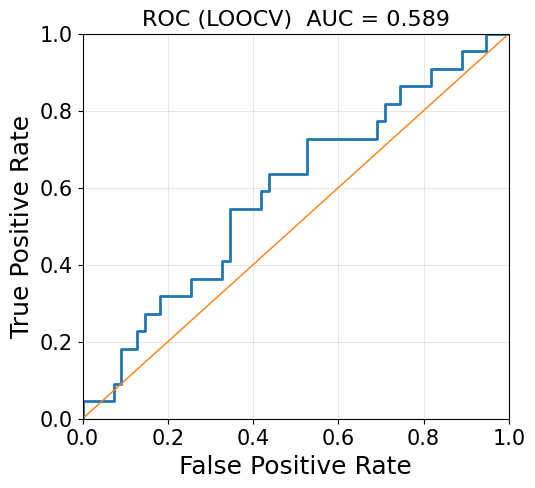


Saved: /content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/LLM_Embeddings/loocv_llm_embedding_lr.npz


In [9]:
import textwrap, os, re, json, math
# ==========================================
# LLM-Embedding Classifier (LOOCV) for your .mat data
# FIXED: Avoids TPM errors by batching requests under a token budget
#   serialize row -> OpenAI embeddings (cached) -> LOOCV LogisticRegression -> metrics
# ==========================================

MAT_PATH = "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/data_bdiat.mat"
OUT_PATH = "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/LLM_Embeddings/loocv_llm_embedding_lr.npz"
CACHE_DIR = "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/LLM_Embeddings/embedding_cache"

# If running in Colab:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os, json, time, hashlib
from dataclasses import dataclass
from typing import List, Optional, Dict, Any, Tuple

import numpy as np
import scipy.io as sio

from tqdm import tqdm
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

# OpenAI python SDK
# pip install openai tqdm scikit-learn scipy matplotlib tiktoken
from openai import OpenAI
import tiktoken
import os
os.environ["OPENAI_API_KEY"] = "Put_Key"


# -----------------------------
# Config
# -----------------------------
@dataclass
class Config:
    embedding_model: str = "text-embedding-3-small"  # or "text-embedding-3-large"
    cache_dir: str = CACHE_DIR

    # Retry/backoff
    max_retries: int = 8
    base_sleep: float = 0.75

    # Token-budget batching (prevents TPM "request too large")
    token_budget: int = 30000  # keep well under your org TPM=40000

    # Row serialization controls
    float_precision: int = 6
    include_feature_index: bool = False
    text_prefix: str = ""
    sep: str = ","


# -----------------------------
# Utilities
# -----------------------------
def ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)

def sha256_text(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

def row_to_text(features: np.ndarray, cfg: Config) -> str:
    """
    Serialize 360 numeric features into a compact text string.
    (Compact form reduces token usage and avoids large batch token counts.)
    """
    features = np.asarray(features).reshape(-1)
    fmt = f"{{:.{cfg.float_precision}f}}"

    if cfg.include_feature_index:
        parts = [f"f{i+1}={fmt.format(float(v))}" for i, v in enumerate(features)]
    else:
        parts = [fmt.format(float(v)) for v in features]

    if cfg.text_prefix:
        return f"{cfg.text_prefix} " + cfg.sep.join(parts)
    return cfg.sep.join(parts)

def get_tokenizer(model: str):
    try:
        return tiktoken.encoding_for_model(model)
    except KeyError:
        return tiktoken.get_encoding("cl100k_base")

def count_tokens(text: str, enc) -> int:
    return len(enc.encode(text))

def make_token_budget_batches(
    indices: List[int],
    texts: List[str],
    enc,
    token_budget: int
) -> List[List[int]]:
    """
    Group indices into batches such that sum(token_count(text)) <= token_budget.
    """
    batches: List[List[int]] = []
    cur: List[int] = []
    cur_tok = 0

    for i in indices:
        nt = count_tokens(texts[i], enc)

        if cur and (cur_tok + nt > token_budget):
            batches.append(cur)
            cur = []
            cur_tok = 0

        cur.append(i)
        cur_tok += nt

    if cur:
        batches.append(cur)

    return batches

def robust_openai_embeddings_create(
    client: OpenAI,
    model: str,
    inputs: List[str],
    cfg: Config,
) -> List[List[float]]:
    """
    Embeddings endpoint with exponential backoff retry.
    """
    for attempt in range(cfg.max_retries):
        try:
            resp = client.embeddings.create(model=model, input=inputs)
            return [d.embedding for d in resp.data]
        except Exception as e:
            sleep_s = cfg.base_sleep * (2 ** attempt) + (0.05 * attempt)
            sleep_s = min(sleep_s, 30.0)
            if attempt == cfg.max_retries - 1:
                raise
            print(f"[warn] embeddings call failed (attempt {attempt+1}/{cfg.max_retries}): {e}")
            print(f"[warn] sleeping {sleep_s:.2f}s then retrying...")
            time.sleep(sleep_s)

    raise RuntimeError("Unreachable: retry loop exhausted")

def get_or_create_embeddings(texts: List[str], cfg: Config) -> np.ndarray:
    """
    Create embeddings for all texts, with per-text on-disk caching.
    Returns: (n_samples, embedding_dim) float32 matrix.
    """
    ensure_dir(cfg.cache_dir)
    client = OpenAI()  # uses OPENAI_API_KEY from env

    embeddings: List[Optional[List[float]]] = [None] * len(texts)
    missing_indices: List[int] = []

    # Load cache when present
    for i, t in enumerate(texts):
        h = sha256_text(cfg.embedding_model + "::" + t)
        fp = os.path.join(cfg.cache_dir, f"{h}.json")
        if os.path.exists(fp):
            with open(fp, "r", encoding="utf-8") as f:
                obj = json.load(f)
            embeddings[i] = obj["embedding"]
        else:
            missing_indices.append(i)

    # Compute missing with token-budget batching
    if missing_indices:
        print(f"Need to embed {len(missing_indices)} / {len(texts)} rows (not in cache).")

        enc = get_tokenizer(cfg.embedding_model)
        batches = make_token_budget_batches(
            indices=missing_indices,
            texts=texts,
            enc=enc,
            token_budget=cfg.token_budget
        )

        for b_idx in tqdm(range(len(batches)), desc="Embedding token-budget batches"):
            batch_idx = batches[b_idx]
            batch_texts = [texts[i] for i in batch_idx]
            batch_embs = robust_openai_embeddings_create(
                client=client,
                model=cfg.embedding_model,
                inputs=batch_texts,
                cfg=cfg,
            )

            for i, emb in zip(batch_idx, batch_embs):
                embeddings[i] = emb
                h = sha256_text(cfg.embedding_model + "::" + texts[i])
                fp = os.path.join(cfg.cache_dir, f"{h}.json")
                with open(fp, "w", encoding="utf-8") as f:
                    json.dump({"model": cfg.embedding_model, "embedding": emb}, f)

    emb_mat = np.array(embeddings, dtype=np.float32)
    if emb_mat.ndim != 2:
        raise RuntimeError(f"Unexpected embedding matrix shape: {emb_mat.shape}")
    return emb_mat


# -----------------------------
# Load your MAT data
# -----------------------------
def load_mat_rows(mat_path: str) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      X: (N, 360) float array from XF
      y_raw: (N,) labels from active_score (raw values)
    """
    D = sio.loadmat(mat_path)
    if "XF" not in D or "active_score" not in D:
        raise KeyError("Expected keys 'XF' and 'active_score' in the .mat file.")

    X = D["XF"].astype(np.float32)          # (N, 360)
    y_raw = D["active_score"].reshape(-1)   # (N,)

    if X.ndim != 2 or X.shape[1] != 360:
        raise ValueError(f"Expected XF shape (N, 360), got {X.shape}")

    classes = np.unique(y_raw)
    if classes.size != 2:
        raise ValueError(f"active_score must have exactly 2 unique values, got: {classes}")

    return X, y_raw


# -----------------------------
# LOOCV classification on embeddings
# -----------------------------
def loocv_classification(E: np.ndarray, y_raw: np.ndarray) -> Dict[str, Any]:
    le = LabelEncoder()
    y = le.fit_transform(y_raw)  # -> 0/1

    loo = LeaveOneOut()
    y_true, y_pred, y_prob = [], [], []

    clf = LogisticRegression(
        class_weight="balanced",
        solver="liblinear",
        max_iter=5000,
        random_state=0,
    )

    for train_idx, test_idx in tqdm(list(loo.split(E)), desc="LOOCV folds"):
        X_train, X_test = E[train_idx], E[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        clf.fit(X_train, y_train)

        pred = int(clf.predict(X_test)[0])
        prob = float(clf.predict_proba(X_test)[0, 1])

        y_true.append(int(y_test[0]))
        y_pred.append(pred)
        y_prob.append(prob)

    y_true = np.array(y_true, dtype=int)
    y_pred = np.array(y_pred, dtype=int)
    y_prob = np.array(y_prob, dtype=float)

    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    auc = roc_auc_score(y_true, y_prob)

    report = classification_report(
        y_true, y_pred, target_names=[str(c) for c in le.classes_], zero_division=0
    )

    return {
        "label_classes": [str(c) for c in le.classes_],
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }


# -----------------------------
# Main
# -----------------------------
def main():
    cfg = Config(
        embedding_model="text-embedding-3-small",
        cache_dir=CACHE_DIR,
        token_budget=30000,  # keep under TPM=40000
        include_feature_index=False,  # compact
        text_prefix="",
        sep=",",
    )

    print("Loading MAT...")
    X, y_raw = load_mat_rows(MAT_PATH)
    N = X.shape[0]
    print(f"Loaded: X={X.shape}, classes={np.unique(y_raw)}")

    print("Serializing rows to text...")
    texts = [row_to_text(X[i], cfg) for i in range(N)]

    print(f"Creating/loading embeddings using model: {cfg.embedding_model}")
    E = get_or_create_embeddings(texts, cfg)
    print(f"Embeddings shape: {E.shape}")

    print("Running LOOCV classification...")
    results = loocv_classification(E, y_raw)

    print("\n=== Performance (LOOCV, Embeddings + Logistic Regression) ===")
    print(f"Classes: {results['label_classes']}")
    print(f"Accuracy:          {results['accuracy']:.4f}")
    print(f"Balanced Accuracy: {results['balanced_accuracy']:.4f}")
    print(f"Precision:         {results['precision']:.4f}")
    print(f"Recall:            {results['recall']:.4f}")
    print(f"F1:                {results['f1']:.4f}")
    print(f"ROC AUC:           {results['roc_auc']:.4f}")
    print("\nConfusion Matrix (rows=true [0,1], cols=pred [0,1]):")
    print(results["confusion_matrix"])
    print("\nClassification Report:")
    print(results["classification_report"])

    # ROC plot
    fpr, tpr, _ = roc_curve(results["y_true"], results["y_prob"])
    plt.figure(figsize=(5.5, 5))
    plt.plot(fpr, tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], linewidth=1)
    plt.title(f"ROC (LOOCV)  AUC = {results['roc_auc']:.3f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1]); plt.ylim([0, 1])
    plt.show()

    # Save outputs
    os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
    np.savez(
        OUT_PATH,
        y_true=results["y_true"],
        y_pred=results["y_pred"],
        y_prob=results["y_prob"],
        auc=np.array([results["roc_auc"]], dtype=np.float64),
        acc=np.array([results["accuracy"]], dtype=np.float64),
        bacc=np.array([results["balanced_accuracy"]], dtype=np.float64),
        embedding_model=np.array([cfg.embedding_model]),
    )
    print(f"\nSaved: {OUT_PATH}")

if __name__ == "__main__":
    main()


In [45]:
import numpy as np
from scipy.io import loadmat
from google.colab import drive

# ---- Mount Drive ----
drive.mount("/content/drive", force_remount=True)

m = loadmat("/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/joint_model_roc.mat", squeeze_me=True, struct_as_record=False)
roc = m["roc"]

np.savez(
    "joint_model_roc.npz",
    fpr=np.asarray(roc.fpr).ravel(),
    tpr=np.asarray(roc.tpr).ravel(),
    thr=np.asarray(roc.thr).ravel(),
    auc=float(roc.auc),
    scores=np.asarray(roc.scores).ravel(),
    labels=np.asarray(roc.labels).ravel(),
)
print("Wrote joint_model_roc.npz")


Mounted at /content/drive
Wrote joint_model_roc.npz


Exception ignored in: <function NpzFile.__del__ at 0x7af79598e7a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close
    self.fid.close()
OSError: [Errno 107] Transport endpoint is not connected
Exception ignored in: <function NpzFile.__del__ at 0x7af79598e7a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close
    self.fid.close()
OSError: [Errno 107] Transport endpoint is not connected


Mounted at /content/drive


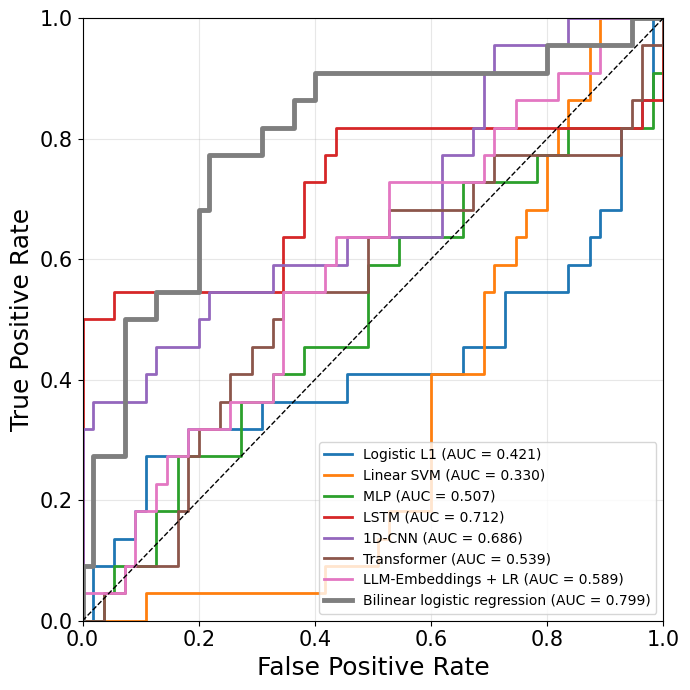

Saved: /content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/Figure_S2.svg


In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

models = [
    ("Logistic L1",
     "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/LogesticL1/loocv_l1_logistic_results.npz"),
    ("Linear SVM",
     "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/SVM/loocv_linear_svm_results.npz"),
    ("MLP",
     "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/MLP/loocv_mlp_results.npz"),
    ("LSTM",
     "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/LSTM/loocv_lstm_results.npz"),
    ("1D-CNN",
     "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/1DCNN/loocv_1dcnn_FAST_noval.npz"),
    ("Transformer",
     "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/Transformer/loocv_transformer_fast.npz"),
    ("LLM-Embeddings + LR",
     "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/LLM_Embeddings/loocv_llm_embedding_lr.npz"),
]

joint_path = "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/joint_model_roc.npz"

plt.figure(figsize=(7, 7))

for name, path in models:
    data = np.load(path, allow_pickle=True)
    keys = set(data.files)

    if "y_true" not in keys:
        print(f"[skip] {name}: missing y_true. keys={sorted(keys)}")
        continue

    y_true = data["y_true"]

    # Score/prob key differences across your saved files
    if "p_hat" in keys:
        scores = data["p_hat"]
    elif "y_prob" in keys:
        scores = data["y_prob"]
    elif "auc_prob" in keys and "p_hat" in keys:  # (not needed, but kept as pattern)
        scores = data["p_hat"]
    else:
        print(f"[skip] {name}: missing p_hat/y_prob. keys={sorted(keys)}")
        continue

    scores = np.asarray(scores).ravel()
    y_true = np.asarray(y_true).ravel()

    fpr, tpr, _ = roc_curve(y_true, scores)
    auc = roc_auc_score(y_true, scores)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

# Joint model
joint = np.load(joint_path, allow_pickle=True)
jfpr = joint["fpr"]; jtpr = joint["tpr"]; jauc = float(joint["auc"])
plt.plot(jfpr, jtpr, linewidth=3.5, label=f"Bilinear logistic regression (AUC = {jauc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()

out_svg = "/content/drive/MyDrive/PNAS_Work/ComparativeAnalysis/Figure_S2.svg"
plt.savefig(out_svg, format="svg")
plt.show()
print("Saved:", out_svg)


### <div style="font-size:40px;">Stimulus Distribution Across Trial Positions</div>

Mounted at /content/drive


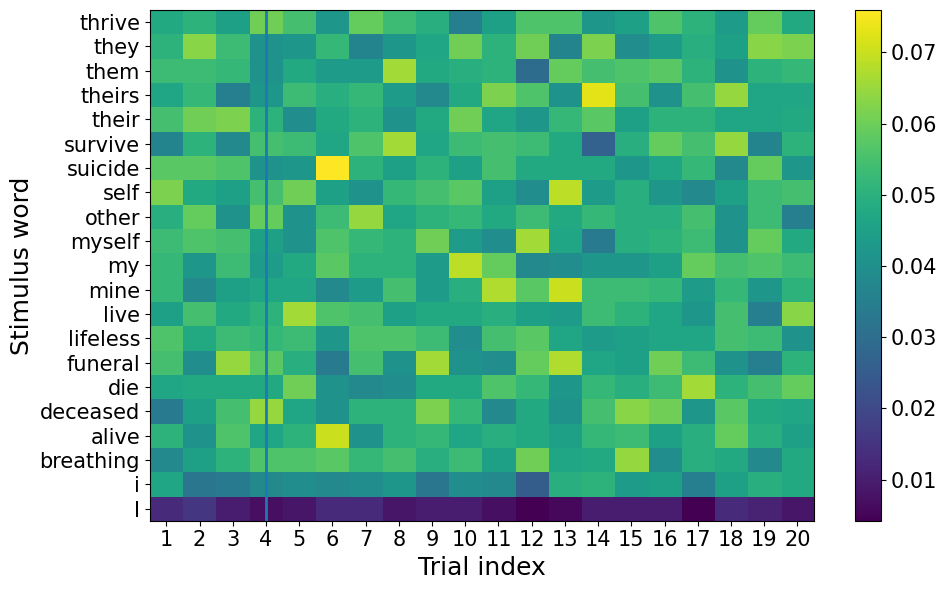

Saved: /mnt/data/Fig_S1_outputs/Fig_S1_A.png
Saved: /mnt/data/Fig_S1_outputs/Fig_S1_A.pdf


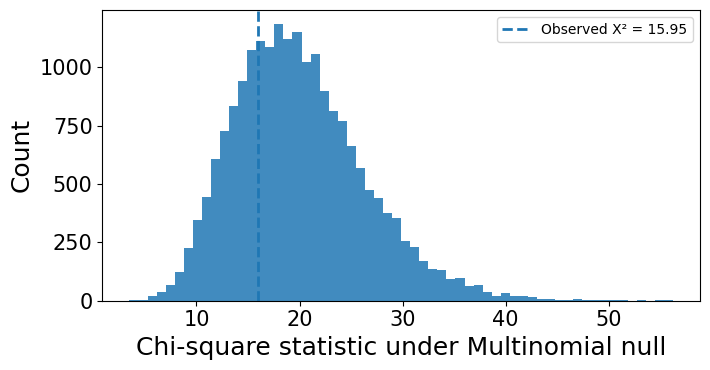

Saved: /mnt/data/Fig_S1_outputs/Fig_S1_B.png
Saved: /mnt/data/Fig_S1_outputs/Fig_S1_B.pdf

DONE. Output folder: /mnt/data/Fig_S1_outputs


In [ ]:
# =========================
# Fig. S4 — Stimulus-position sanity check
# Plots:
#   (1) Heatmap: P(word | trial position)
#   (2) MC null histogram of chi-square under Multinomial(n4, p_not4) + observed line
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import chi2
from google.colab import drive

# ---- Mount Drive ----
drive.mount("/content/drive", force_remount=True)
# -----------------------
# CONFIG
# -----------------------
XLSX_PATH = Path("/content/drive/MyDrive/PNAS_Work/Words_simulation/Stimulus-Position-20.xlsx")

OUT_DIR = Path("/mnt/data/Fig_S1_outputs")  # change to Drive if you want
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_TRIAL = 4
N_MC = 20000          # Monte-Carlo samples
RANDOM_SEED = 42
TOPK_LABEL = 8        # label most deviant words in scatter
EPS = 1e-12

np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "axes.titlesize": 16,
})

# -----------------------
# Load wide stimulus-position table
# Expected: rows=trial positions (1..20), cols=words (counts)
# -----------------------
df = pd.read_excel(XLSX_PATH, sheet_name=0)

# Identify trial-position column
pos_col = None
for c in df.columns:
    if str(c).strip().lower() in ["position", "trial", "trial_position", "trial position", "pos"]:
        pos_col = c
        break
if pos_col is None:
    pos_col = df.columns[0]

df = df.copy()
df[pos_col] = pd.to_numeric(df[pos_col], errors="coerce").astype(int)

word_cols = [c for c in df.columns if c != pos_col]
for c in word_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

df = df.sort_values(pos_col).reset_index(drop=True)

trials = df[pos_col].to_numpy()
words = np.array(word_cols, dtype=str)
counts = df[word_cols].to_numpy(dtype=float)  # (T, W)

if TARGET_TRIAL not in trials:
    raise ValueError(f"TARGET_TRIAL={TARGET_TRIAL} not found in trial positions: {trials.tolist()}")

t4_idx = int(np.where(trials == TARGET_TRIAL)[0][0])

# -----------------------
# Helper functions
# -----------------------
def safe_div(a, b):
    return np.divide(a, b, out=np.zeros_like(a, dtype=float), where=(b > 0))

def cosine_sim(p, q):
    p = np.asarray(p, float)
    q = np.asarray(q, float)
    np_ = np.linalg.norm(p)
    nq_ = np.linalg.norm(q)
    if np_ < EPS or nq_ < EPS:
        return np.nan
    return float(np.dot(p, q) / (np_ * nq_))

def chisq_stat(obs_counts, p_null):
    """Pearson chi-square statistic comparing obs to expected n*p_null."""
    n = obs_counts.sum()
    exp = n * p_null
    mask = exp > 1e-9
    if mask.sum() < 2:
        return np.nan
    return float(np.sum((obs_counts[mask] - exp[mask])**2 / (exp[mask] + EPS)))

def chisq_pvalue_from_stat(x2, df_):
    return float(1.0 - chi2.cdf(x2, df_))

# -----------------------
# Build distributions
# -----------------------
row_sums = counts.sum(axis=1, keepdims=True)
P_word_given_trial = safe_div(counts, row_sums)  # (T, W)

# p(word | trial=4)
p_t4 = P_word_given_trial[t4_idx, :].copy()
n4 = int(counts[t4_idx, :].sum())
obs_counts_t4 = counts[t4_idx, :].astype(int)

# p(word | not trial=4) pooled distribution
counts_not4 = np.delete(counts, t4_idx, axis=0).sum(axis=0)
p_not4 = safe_div(counts_not4, counts_not4.sum()).copy()

# Cosine similarity (effect size)
cos_val = cosine_sim(p_t4, p_not4)

# -----------------------
# Chi-square GOF test (classical)
# Null: trial-4 counts ~ Multinomial(n4, p_not4)
# -----------------------
x2_obs = chisq_stat(obs_counts_t4, p_not4)

# Degrees of freedom: (number of categories with expected>0) - 1
exp = n4 * p_not4
df_chi = int(np.sum(exp > 1e-9) - 1)
p_chi = chisq_pvalue_from_stat(x2_obs, df_chi) if np.isfinite(x2_obs) and df_chi >= 1 else np.nan

# -----------------------
# Monte-Carlo multinomial test (robust)
# -----------------------
mc_stats = None
p_mc = np.nan
if N_MC > 0 and n4 > 0 and np.isfinite(x2_obs) and df_chi >= 1:
    mc_counts = np.random.multinomial(n4, p_not4, size=N_MC)
    # compute chi-square stats for each MC sample against same expected n4*p_not4
    mask = exp > 1e-9
    exp_mask = exp[mask]
    mc_stats = np.sum((mc_counts[:, mask] - exp_mask)**2 / (exp_mask + EPS), axis=1)
    # right-tail p-value with +1 correction
    p_mc = float((np.sum(mc_stats >= x2_obs) + 1) / (N_MC + 1))

# =========================
# (1) HEATMAP: P(word | trial)
# =========================
# Order words by overall frequency to make heatmap easier to read
overall_counts = counts.sum(axis=0)
order = np.argsort(overall_counts)[::-1]
words_sorted = words[order]
P_sorted = P_word_given_trial[:, order].T  # (W, T) for heatmap

plt.figure(figsize=(10, max(6, 0.25 * len(words_sorted))))
im = plt.imshow(P_sorted, aspect="auto", interpolation="nearest")
plt.colorbar(im, label="")
plt.xticks(np.arange(len(trials)), trials)
plt.yticks(np.arange(len(words_sorted)), words_sorted)
plt.xlabel("Trial index")
plt.ylabel("Stimulus word")

# highlight TARGET_TRIAL column
x_idx = int(np.where(trials == TARGET_TRIAL)[0][0])
plt.axvline(x_idx, linewidth=2)

plt.tight_layout()
heat_png = OUT_DIR / "Fig_S1_A.png"
heat_pdf = OUT_DIR / "Fig_S1_A.pdf"
plt.savefig(heat_png, dpi=300)
plt.savefig(heat_pdf)
plt.savefig("Figure_S1_A.svg")
plt.show()

print("Saved:", heat_png)
print("Saved:", heat_pdf)

# =========================
# (2) MC NULL DISTRIBUTION: histogram of chi-square stats
# =========================
if mc_stats is None:
    print("MC histogram skipped (N_MC <= 0 or insufficient counts).")
else:
    plt.figure(figsize=(7.2, 3.8))
    plt.hist(mc_stats, bins=60, alpha=0.85)
    plt.axvline(x2_obs, linewidth=2, linestyle="--", label=f"Observed X² = {x2_obs:.2f}")
    plt.xlabel("Chi-square statistic under Multinomial null")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()

    mc_png = OUT_DIR / "Fig_S1_B.png"
    mc_pdf = OUT_DIR / "Fig_S1_B.pdf"
    plt.savefig(mc_png, dpi=300)
    plt.savefig(mc_pdf)
    plt.savefig("Figure_S1_B.svg")
    plt.show()

    print("Saved:", mc_png)
    print("Saved:", mc_pdf)

print("\nDONE. Output folder:", OUT_DIR)
